# Cleaned Realtor Data Notebook

This notebook prepares the cleaned housing dataset used by the rest of the BUSA 695 capstone project. It loads `realtor_master.csv`, applies basic data checks and filtering, creates a simplified modeling file, and explores a few early relationships in the cleaned data.

**Dataset loaded:** `realtor_master.csv`

**Main steps:**
- Load the cleaned master dataset.
- Create `cleaned_simple.csv` without location fields for simpler modeling work.
- Convert selected status fields to numeric values.
- Filter unrealistic values and large outliers.
- Review summary statistics, missing values, correlations, and sample scatterplots.

**Outputs created:** `cleaned_simple.csv` and notebook-based exploratory results.

**Capstone connection:** This notebook documents the cleaned dataset that supports downstream modeling, random forest analysis, and mapping work across the overall BUSA 695 project.
            

In [144]:
import os 
import pandas as pd    
import csv

## Load Source Data

This section opens the cleaned master file that will be reviewed and filtered in the rest of the notebook.
            

In [145]:
# Load the cleaned master dataset that supports later project notebooks.
cleaned_df = pd.read_csv("realtor_master.csv", low_memory=False)
cleaned_df

,price,bed,bath,acre_lot,city,state,zip_code,house_size,status_for_sale,status_ready_to_build,status_sold
0,105000.0,3.0,2.0,0.12,Adjuntas,Puerto Rico,601.0,920.0,True,False,False
1,80000.0,4.0,2.0,0.08,Adjuntas,Puerto Rico,601.0,1527.0,True,False,False
2,67000.0,2.0,1.0,0.15,Juana Diaz,Puerto Rico,795.0,748.0,True,False,False
3,145000.0,4.0,2.0,0.10,Ponce,Puerto Rico,731.0,1800.0,True,False,False
4,65000.0,6.0,2.0,0.05,Mayaguez,Puerto Rico,680.0,1760.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
2224836,359900.0,4.0,2.0,0.33,Richland,Washington,99354.0,3600.0,False,False,True
2224837,350000.0,3.0,2.0,0.10,Richland,Washington,99354.0,1616.0,False,False,True
2224838,440000.0,6.0,3.0,0.50,Richland,Washington,99354.0,3200.0,False,False,True
2224839,179900.0,2.0,1.0,0.09,Richland,Washington,99354.0,933.0,False,False,True


In [146]:
# Save a simplified file for modeling steps that do not use location variables.
#create simple dataset (no location -- for LM)
simple_df = cleaned_df.drop(columns=["city", "state", "zip_code"])
#saving new csv with no location 
simple_df.to_csv("cleaned_simple.csv", index=False)

## Create a Simplified Modeling File

This section removes location fields to create a simpler dataset for modeling workflows that do not need city, state, or zip code.
            

In [147]:
#Decoding status variables from boolean to integer  (1/0)
cleaned_df[["status_for_sale","status_ready_to_build","status_sold"]] = cleaned_df[["status_for_sale","status_ready_to_build","status_sold"]].astype(int)

## Convert Status Fields and Review the Dataset

This section changes selected boolean-style status fields into numeric values and checks summary statistics before deeper filtering.
            

In [148]:
# Apply value filters to remove unrealistic property records before exploration.
cleaned_df.describe()

,price,bed,bath,acre_lot,house_size,status_for_sale,status_ready_to_build,status_sold
count,2.224841e+06,2.224841e+06,2.224841e+06,2.224841e+06,2.224841e+06,2.224841e+06,2.224841e+06,2.224841e+06
mean,5.241955e+05,3.216198e+00,2.382559e+00,1.303007e+01,2.471169e+03,6.240262e-01,1.111001e-02,3.648638e-01
std,2.138893e+06,1.392517e+00,1.465584e+00,7.050674e+02,6.976357e+05,4.843734e-01,1.048169e-01,4.813921e-01
min,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.650000e+05,3.000000e+00,2.000000e+00,1.700000e-01,1.456000e+03,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.250000e+05,3.000000e+00,2.000000e+00,2.600000e-01,1.760000e+03,1.000000e+00,0.000000e+00,0.000000e+00
75%,5.500000e+05,4.000000e+00,3.000000e+00,6.800000e-01,2.140000e+03,1.000000e+00,0.000000e+00,1.000000e+00
max,2.147484e+09,4.730000e+02,8.300000e+02,1.000000e+05,1.040400e+09,1.000000e+00,1.000000e+00,1.000000e+00


In [149]:
#cleaned_df = cleaned_df[cleaned_df["bed"] <= 10]
#cleaned_df = cleaned_df[cleaned_df["bath"] <= 10]

## Filter Unrealistic Property Values

These steps remove records with implausible bedroom, bathroom, lot size, house size, or price values so later analysis is based on more reasonable observations.
            

In [150]:
cleaned_df = cleaned_df[
    (cleaned_df["bed"] > 0) & (cleaned_df["bed"] <= 10)
]

cleaned_df = cleaned_df[
    (cleaned_df["bath"] > 0) & (cleaned_df["bath"] <= 10)
]

In [151]:
print(cleaned_df.shape)

(2220146, 11)


In [152]:

#Price cap (removing extreme house prices (outliers)
cleaned_df = cleaned_df[cleaned_df["price"] <=2000000]

#Lot size cap (removing extreme land properties 
cleaned_df = cleaned_df[cleaned_df["acre_lot"] <=10 ]

#House size cap (removing unrealistic house size)
cleaned_df = cleaned_df[cleaned_df["house_size"] <= 10000]

In [153]:
print(cleaned_df.shape)

(2051812, 11)


In [154]:
cleaned_df.describe()

,price,bed,bath,acre_lot,house_size,status_for_sale,status_ready_to_build,status_sold
count,2.051812e+06,2.051812e+06,2.051812e+06,2.051812e+06,2.051812e+06,2.051812e+06,2.051812e+06,2.051812e+06
mean,3.932394e+05,3.168604e+00,2.318877e+00,7.346480e-01,1.887913e+03,6.091640e-01,1.200159e-02,3.788344e-01
std,3.403911e+05,9.606434e-01,9.055528e-01,1.435446e+00,8.237582e+02,4.879378e-01,1.088924e-01,4.850969e-01
min,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.599000e+05,3.000000e+00,2.000000e+00,1.600000e-01,1.420000e+03,0.000000e+00,0.000000e+00,0.000000e+00
50%,3.149000e+05,3.000000e+00,2.000000e+00,2.600000e-01,1.760000e+03,1.000000e+00,0.000000e+00,0.000000e+00
75%,5.150000e+05,4.000000e+00,3.000000e+00,5.000000e-01,2.110000e+03,1.000000e+00,0.000000e+00,1.000000e+00
max,2.000000e+06,1.000000e+01,1.000000e+01,1.000000e+01,1.000000e+04,1.000000e+00,1.000000e+00,1.000000e+00


## Explore Relationships in the Cleaned Data

The remaining cells review correlations, create sample scatterplots, and check missing values after filtering.
            

In [155]:
#Correlation between columns (variables)
cleaned_df.corr(numeric_only=True)

#the correlation price vs bath is 47%
#the correlation price vs house size is 43%
#the correlation price vs bed is 28%??  

#based on the correlation our strongest correlations are price vs bath and price vs house size

,price,bed,bath,acre_lot,house_size,status_for_sale,status_ready_to_build,status_sold
price,1.000000,0.278991,0.470787,-0.033337,0.431334,-0.067340,0.035053,0.059866
bed,0.278991,1.000000,0.586443,-0.003844,0.618895,0.009870,0.038336,-0.018533
bath,0.470787,0.586443,1.000000,-0.007946,0.706975,0.011664,-0.038811,-0.003020
acre_lot,-0.033337,-0.003844,-0.007946,1.000000,0.068583,0.114906,-0.036444,-0.107398
house_size,0.431334,0.618895,0.706975,0.068583,1.000000,0.033845,0.065604,-0.048770
status_for_sale,-0.067340,0.009870,0.011664,0.114906,0.033845,1.000000,-0.137598,-0.974969
status_ready_to_build,0.035053,0.038336,-0.038811,-0.036444,0.065604,-0.137598,1.000000,-0.086072
status_sold,0.059866,-0.018533,-0.003020,-0.107398,-0.048770,-0.974969,-0.086072,1.000000


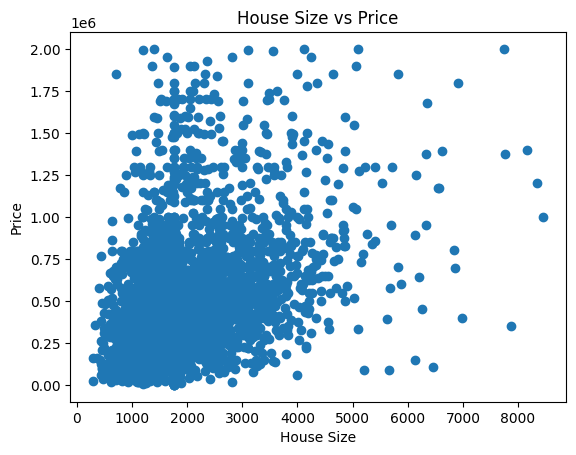

In [156]:
import matplotlib.pyplot as plt

sample_df = cleaned_df.sample(5000)
plt.scatter(sample_df["house_size"], sample_df["price"])
plt.xlabel("House Size")
plt.ylabel("Price")
plt.title("House Size vs Price")
plt.show()

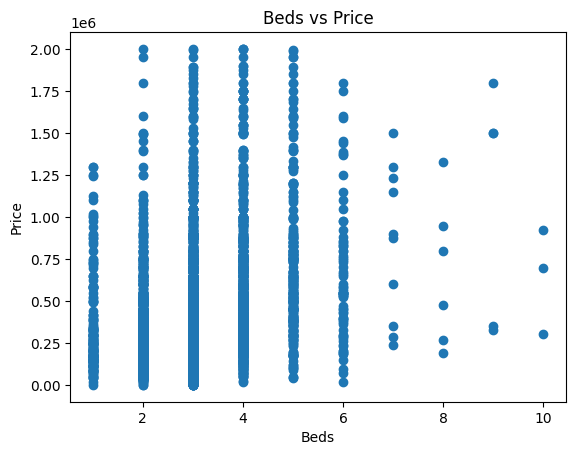

In [157]:
sample_df = cleaned_df.sample(5000)
plt.scatter(sample_df["bed"], sample_df["price"])
plt.xlabel("Beds")
plt.ylabel("Price")
plt.title("Beds vs Price")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

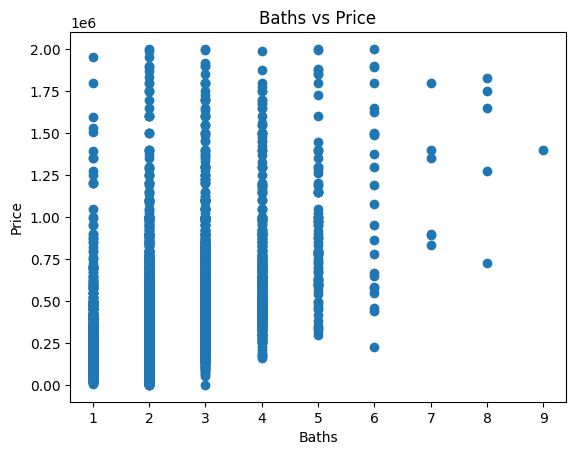

In [158]:
sample_df = cleaned_df.sample(5000)
plt.scatter(sample_df["bath"], sample_df["price"])
plt.xlabel("Baths")
plt.ylabel("Price")
plt.title("Baths vs Price")
plt.show

In [159]:
cleaned_df.isnull().sum()

price                    0
bed                      0
bath                     0
acre_lot                 0
city                     0
state                    0
zip_code                 0
house_size               0
status_for_sale          0
status_ready_to_build    0
status_sold              0
dtype: int64